In [15]:
import numpy as np
import matplotlib.pyplot as plt

SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

## 1. 파형 읽기

=== TRACE INFO ===
type: <class 'numpy.memmap'>
dtype: float32
ndim : 2
shape: (5000, 3224)


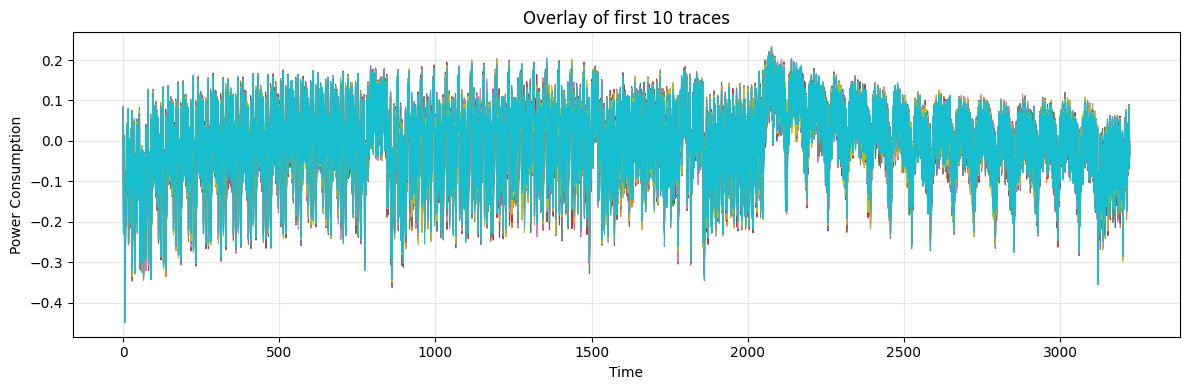

In [16]:
# 1. 파형 정보 읽고 그래프 그리기
FILE_PATH = "ML_trace.npy"
traces = np.load(FILE_PATH, mmap_mode="r") 

print("=== TRACE INFO ===")
print("type:", type(traces))
print("dtype:", traces.dtype)
print("ndim :", traces.ndim)
print("shape:", traces.shape)

# 파형 그래프 그리기
k = 10  # 앞에서 k개만 겹쳐서 보기
plt.figure(figsize=(12, 4)) # 그래프 크기 (가로 12인치, 세로 4인치)
for i in range(k):
    plt.plot(traces[i], linewidth=0.8)  
plt.title(f"Overlay of first {k} traces")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.grid(True, alpha=0.3) # 눈금선 투명도 0.3으로 표시
plt.tight_layout() # 그래프의 제목/라벨 등 자동 여백 조정
plt.show()

In [17]:
# 2. 평문과 키를 읽고 중간값 계산하기 
plaintexts = np.load("ML_plain.npy") # (5000, 16) 
keys = np.load("ML_key.npy") # (5000, 16) -> 고정키 

def interm_and_onehot(
    plaintexts: np.ndarray,   
    keys: np.ndarray,         
    byte_idx: int           
) -> tuple[np.ndarray, np.ndarray]:
    fixed_key = keys[0]                                # 16 바이트 고정 키 (첫 행이 실제 키)
    key_byte  = fixed_key[byte_idx]                 
    pt_byte   = plaintexts[:, byte_idx]             # 모든 평문에서 byte_index번째 바이트만 추출

    x = np.bitwise_xor(pt_byte, key_byte)          
    interm_value = SBOX[x]                          # (N,) 0~255 사이의 SBOX 출력

    onehot = np.eye(256, dtype=np.float32)[interm_value]  # 원핫인코딩 라벨링 (N, 256)

    return interm_value, onehot

interm shape: (5000,)
onehot shape: (5000, 256)
interm[0] = 76
onehot[0] 1의 위치 = 76


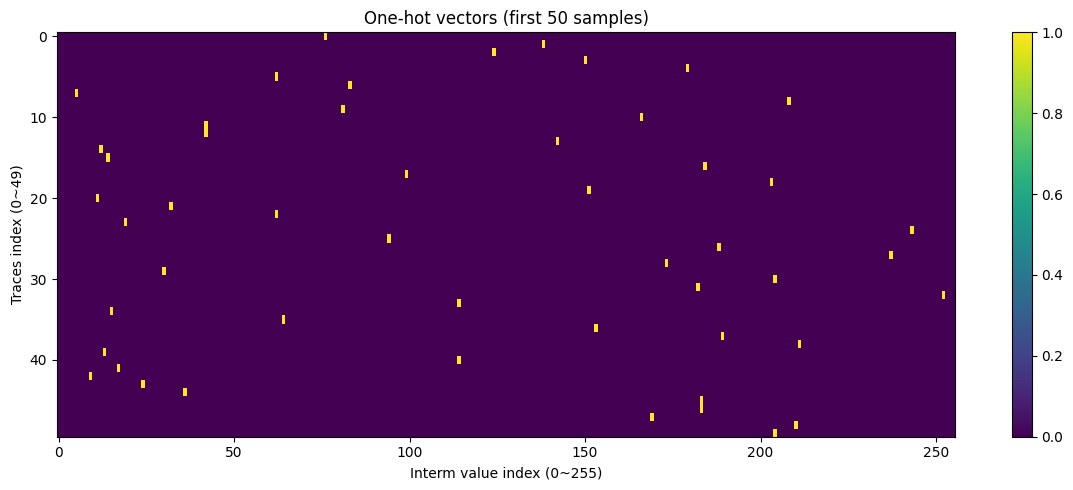

In [18]:
# One-hot encoding 및 변화된 값 확인
byte_idx = 0 # 특정 바이트
interm_value, onehot = interm_and_onehot(plaintexts, keys, byte_idx)

onehot = np.eye(256, dtype=np.float32)[interm_value] # One-hot encoding: (N, 256) 
print("interm shape:", interm_value.shape) # 평문과 실제 키에 대한 중간값 (각 트레이스의 라벨)
print("onehot shape:", onehot.shape) # 각 중간값을 256차원 원핫으로 변환 

trace_idx = 0
print(f"interm[{trace_idx}] =", int(interm_value[trace_idx])) # trace_idx번째 파형에 대한 중간값
print(f"onehot[{trace_idx}] 1의 위치 =", int(onehot[trace_idx].argmax())) # 중간값에 대응하는 1의 위치

# m개의 중간값 원핫인코딩 결과 시각화
m = 50
m_eff = min(m, onehot.shape[0])  # m이 5000보다 커도 처리
plt.figure(figsize=(12, 5))
plt.imshow(onehot[:m_eff], aspect='auto', interpolation='nearest')
plt.title(f"One-hot vectors (first {m_eff} samples)")
plt.xlabel("Interm value index (0~255)")
plt.ylabel(f"Traces index (0~{m_eff-1})")
plt.colorbar()
plt.tight_layout()
plt.show()

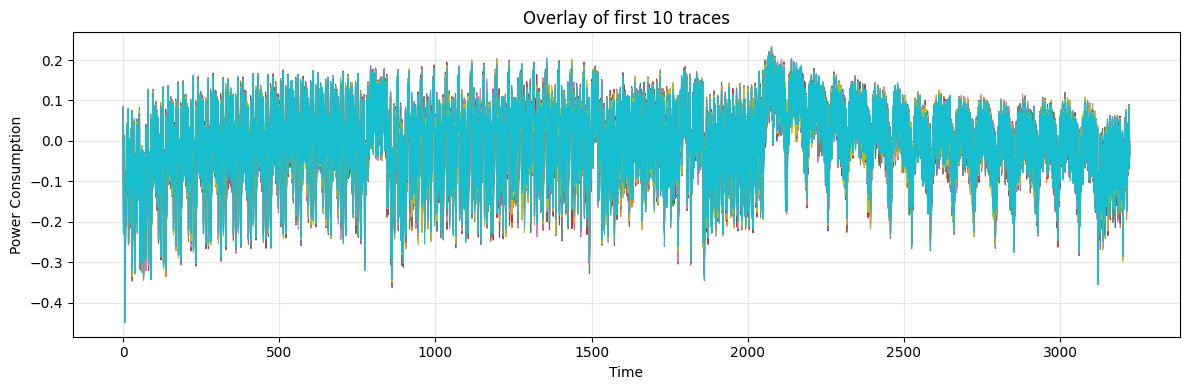

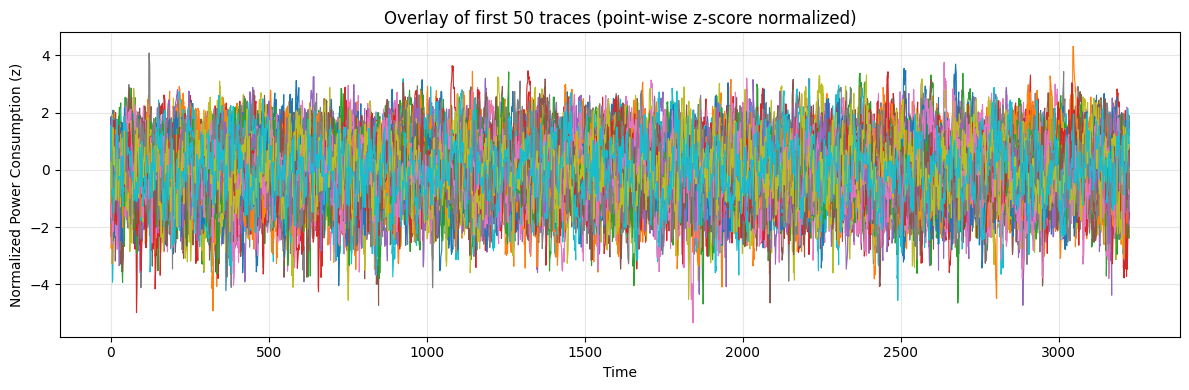

check points: [0, 500, 1000, 2000, 3000]
mean per point: [ 7.4615480e-07  6.4849854e-07  4.7302247e-08  5.8441162e-07
 -2.5863648e-07]
std  per point: [1.0000101  0.999998   1.         0.99999774 1.0000013 ]


In [19]:
# 3. 파형을 표준 정규분포로 정규화

# 1) 정규화 전: 첫 k개 오버레이
plt.figure(figsize=(12, 4))
for i in range(k):
    plt.plot(traces[i], linewidth=0.8)
plt.title(f"Overlay of first {k} traces")
plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 포인트별 표준화(z-score): axis=0 기준
#    mu/std는 (L,)이고, (N,L)에서 자동 broadcast됨
mu = traces.mean(axis=0)          # (L,) 세로 방향(트레이스 방향)으로 평균을 냄 -> 각 시간 포인트 t마다 평균 (t번째 샘플에서 5000개 트레이스의 평균값)
std = traces.std(axis=0)          # (L,) t번째 샘플에서 5000개 트레이스의 표준편차(퍼짐 정도)
eps = 1e-8 # 분모 0 방지

traces_norm = (traces - mu) / (std + eps)  # (5000, 3224) 정규화

# 3) 정규화 후: 첫 k개 오버레이
k = 50  # 겹칠 트레이스 개수
plt.figure(figsize=(12, 4))
for i in range(k):
    plt.plot(traces_norm[i], linewidth=0.8)
plt.title(f"Overlay of first {k} traces (point-wise z-score normalized)")
plt.xlabel("Time")
plt.ylabel("Normalized Power Consumption (z)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4) 정규화가 잘 됐는지 간단 검증 (임의 포인트 몇 개)
#    각 포인트 t에서, (traces[:,t]-mu[t])/(std[t]+eps)의 평균≈0, 표준편차≈1
time_idx = np.array([0, 500, 1000, 2000, 3000])  # 확인할 포인트(원하면 바꿔도 됨)
z = (traces[:, time_idx] - mu[time_idx]) / (std[time_idx] + eps)  # (N, 5)  해당 포인트들의 z-score 계산
print("check points:", time_idx.tolist())
print("mean per point:", z.mean(axis=0))
print("std  per point:", z.std(axis=0))

## 2. 신경망 학습시키기

In [20]:
# TF 내부 로그/경고 숨기기 (tensorflow import 전에)
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 2=INFO+WARNING 숨김 (GPU INFO도 보통 여기서 사라짐)

import warnings
warnings.filterwarnings("ignore", message=".*triggered tf.function retracing.*")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import tensorflow as tf
tf.get_logger().setLevel("ERROR")  # TF 파이썬 로거도 ERROR만

# 전역 XLA 끄기 (import 이후에)
try:
    tf.config.optimizer.set_jit(False)
except Exception:
    pass

from tensorflow.keras import layers, models, regularizers

In [21]:
# X, split index는 1번만 만듦
X = np.asarray(traces_norm, dtype=np.float32)     # (5000, 3224) 정규화된 파형을 모아 놓은 입력 데이터 배열
pt = plaintexts.astype(np.uint8, copy=False)      # (5000, 16)
true_key = keys[0].astype(np.uint8)               # (16,)

N = X.shape[0] # X의 첫번째 차원 크기(5000)
rng = np.random.default_rng(78) # 난수 생성기를 만들고 시드 고정 (결과 비교를 위해 고정)
idx = rng.permutation(N) # 0~N-1을 랜덤하게 섞은 배열

# train 80%, val 10%, test 10%
n_train = int(0.8 * N)
n_val   = int(0.1 * N) # val: 검증용(학습 중에 성능을 점검하는 데이터)
# 나머지는 자동으로 test (최종 평가용)

# 실제 데이터 배열을 인덱싱해서 train/val/test 데이터 생성
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train + n_val]
test_idx  = idx[n_train + n_val:]

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx] # 어떤 파형이 train/val/test로 갈지를 담은 인덱스 배열
pt_train, pt_val, pt_test = pt[train_idx], pt[val_idx], pt[test_idx]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_train: (4000, 3224) X_val: (500, 3224) X_test: (500, 3224)


In [22]:
# 단일 바이트 분류 모델(출력 256) 생성
def build_singlebyte_model(input_len: int,
                           hidden: int = 400,
                           depth: int = 2,
                           dropout: float = 0.55,
                           l2: float = 5e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_len,)))
    for _ in range(depth):
        model.add(layers.Dense(hidden, activation="relu",
                               kernel_regularizer=regularizers.l2(l2)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(256, activation="softmax"))
    return model

"""
기본 모델 정의
model = models.Sequential([
    layers.Input(shape=(X.shape[1],)), # 입력 한 샘플의 모양 지정 (3224,)
    layers.Dense(400, activation="relu", kernel_regularizer=regularizers.l2(5e-3)), # 3224차원을 입력 받아, 400개의 특징으로 변환
    #                                    Dense의 가중치(weight, kernel)가 너무 커지지 않게 벌점을 주는 규제 -> 과적합을 줄이기 위함
    layers.Dropout(0.55), # 뉴런의 55%를 드롭아웃 (과적합 방지)
    layers.Dense(400, activation="relu", kernel_regularizer=regularizers.l2(5e-3)),
    layers.Dropout(0.55),
    layers.Dense(400, activation="relu", kernel_regularizer=regularizers.l2(5e-3)),
    layers.Dropout(0.55),
    layers.Dense(256, activation="softmax"),    # 클래스가 256개이므로 출력 노드도 256개
    #                             softmax는 256개 출력이 확률처럼 합이 1이 되게 만들어줌
])
"""

'\n기본 모델 정의\nmodel = models.Sequential([\n    layers.Input(shape=(X.shape[1],)), # 입력 한 샘플의 모양 지정 (3224,)\n    layers.Dense(400, activation="relu", kernel_regularizer=regularizers.l2(5e-3)), # 3224차원을 입력 받아, 400개의 특징으로 변환\n    #                                    Dense의 가중치(weight, kernel)가 너무 커지지 않게 벌점을 주는 규제 -> 과적합을 줄이기 위함\n    layers.Dropout(0.55), # 뉴런의 55%를 드롭아웃 (과적합 방지)\n    layers.Dense(400, activation="relu", kernel_regularizer=regularizers.l2(5e-3)),\n    layers.Dropout(0.55),\n    layers.Dense(400, activation="relu", kernel_regularizer=regularizers.l2(5e-3)),\n    layers.Dropout(0.55),\n    layers.Dense(256, activation="softmax"),    # 클래스가 256개이므로 출력 노드도 256개\n    #                             softmax는 256개 출력이 확률처럼 합이 1이 되게 만들어줌\n])\n'

In [23]:
# 단일 바이트 대상 모델 학습 함수
def train_model(
    X_train, Y_train,
    X_val,   Y_val,
    X_test,  Y_test,
    input_len: int,
    hidden=400, depth=3,
    dropout=0.5, l2=5e-3,
    lr=1e-3,
    epochs=80,
    batch_size=128,
    verbose=0
):

    # (1) 모델 만들기
    tf.keras.backend.clear_session()
    model = build_singlebyte_model(
        input_len=input_len,
        hidden=hidden, depth=depth,
        dropout=dropout, l2=l2
    )

    # (2) 컴파일
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr), # optimizer: 가중치를 어떻게 업데이트할지 정하는 알고리즘
        loss="categorical_crossentropy", # 원핫 라벨이므로
        metrics=["accuracy"], # 학습 중에 맞춘 비율(정확도)을 함께 출력
        jit_compile=False, # XLA/JIT 끄기
    )

    # (3) 콜백
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            # val_loss(검증 손실)를 계속 보다가, 성능이 8 epoch 동안 개선되지 않으면 학습을 멈춤
            monitor="val_loss", patience=8, restore_best_weights=True
            #                               멈춘 뒤 val_loss가 가장 낮았던 epoch의 가중치로 되돌림
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            # val_loss가 3 epoch 동안 개선이 없으면 learning rate를 절반(factor=0.5)으로 줄임
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
        )
    ]

    # (4) 학습
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    # (5) 평가
    tr_loss, tr_acc = model.evaluate(X_train, Y_train, verbose=0)
    va_loss, va_acc = model.evaluate(X_val,   Y_val,   verbose=0)
    te_loss, te_acc = model.evaluate(X_test,  Y_test,  verbose=0)

    metrics = {
        "train_acc": float(tr_acc),
        "val_acc":   float(va_acc),
        "test_acc":  float(te_acc),
        "history":   history,
    }
    return model, metrics

## 3. 학습된 신경망으로 키 분석하기

In [24]:
# 모델이 낸 중간값 확률 배열 probs를 후보키별 log-likelihood 배열로 바꿔주는 함수: probs -> loglik (N,256)
def loglik_matrix_from_probs(probs, pt_attack, byte_index, eps=1e-36):
    """
    probs: (N,256) = model.predict 결과
    반환: loglik (N,256)
      loglik[i,k] = log p_i( O_i(k) ),  O_i(k)=SBOX[pt_i_byte xor k]
    """
    probs = np.clip(probs, eps, 1.0) # 확률값을 [eps, 1.0] 범위로 제한
    log_probs = np.log(probs)  # (N,256)
    N = log_probs.shape[0]

    pt_byte = pt_attack[:, byte_index].astype(np.uint8) # (N,) 평문 바이트 추출
    guesskeys = np.arange(256, dtype=np.uint8) # (256,)
    interm = SBOX[np.bitwise_xor(guesskeys[:, None], pt_byte[None, :])]  # (256,5000) k번째 후보키를 가정했을 때 i번째 파형(평문)의 중간값

    loglik = log_probs[np.arange(N)[:, None], interm.T] # (5000,256) loglik[i,k] = i번째 트레이스가 후보키 k를 지지하는 로그확률
    return loglik

In [25]:
# Guessing Entropy: 공격을 여러 번 수행했을 때 후보키의 평균 등수
# Success Rate: 공격 성공률 (비밀키가 1등인 비율)
def compute_ge_sr(loglik, true_key_byte, n_runs=50, steps=None, seed=1234):
    N = loglik.shape[0]

    # 성능을 평가할 트레이스 개수 t(=steps) 목록
    if steps is None:
        steps = np.arange(1, N + 1, dtype=int) # 1부터 N까지 전부 평가
    else:
        steps = np.asarray(steps, dtype=int)
        steps = steps[(steps >= 1) & (steps <= N)]
        steps = np.unique(steps) # 중복 제거
        steps.sort()

    ge = np.zeros(len(steps), dtype=np.float64)
    sr = np.zeros(len(steps), dtype=np.float64)

    rng = np.random.default_rng(seed)

    for _ in range(n_runs): # n_runs번 공격 반복
        perm = rng.permutation(N) # 트레이스 순서 섞기
        cumsum_scores = np.cumsum(loglik[perm], axis=0)     # (N,256) 누적 점수
        scores_t = cumsum_scores[steps - 1]                 # (T,256)

        true_scores = scores_t[:, int(true_key_byte)]       # (T,) 정답키 점수만 뽑기
        ranks = 1 + np.sum(scores_t > true_scores[:, None], axis=1)  # 정답키 점수보다 더 큰 점수를 가진 후보의 개수
        ge += ranks
        sr += (ranks == 1)

    ge /= n_runs
    sr /= n_runs
    return steps, ge, sr


===== BYTE 00 =====
acc train/val/test = 0.9995 / 0.9720 / 0.9760
[byte 00] best=0x2b  top5=['0x2b', '0x0b', '0xab', '0x29', '0x2f']

===== BYTE 01 =====
acc train/val/test = 0.9990 / 0.9240 / 0.9180
[byte 01] best=0x7e  top5=['0x7e', '0x3e', '0x5e', '0x6e', '0x7c']

===== BYTE 02 =====
acc train/val/test = 0.9970 / 0.9000 / 0.8880
[byte 02] best=0x15  top5=['0x15', '0x35', '0x55', '0x14', '0x17']

===== BYTE 03 =====
acc train/val/test = 0.9942 / 0.8300 / 0.8180
[byte 03] best=0x16  top5=['0x16', '0x36', '0x56', '0x12', '0x26']

===== BYTE 04 =====
acc train/val/test = 0.9803 / 0.7820 / 0.7740
[byte 04] best=0x28  top5=['0x28', '0x08', '0x38', '0x2c', '0x68']

===== BYTE 05 =====
acc train/val/test = 0.9998 / 0.9120 / 0.9060
[byte 05] best=0xae  top5=['0xae', '0x8e', '0xee', '0xac', '0xaa']

===== BYTE 06 =====
acc train/val/test = 0.9955 / 0.8840 / 0.8860
[byte 06] best=0xd2  top5=['0xd2', '0xf2', '0x92', '0xc2', '0xd0']

===== BYTE 07 =====
acc train/val/test = 0.9837 / 0.7380 / 0.

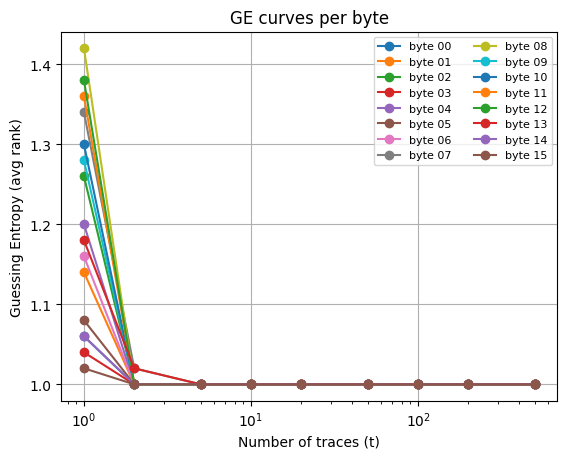

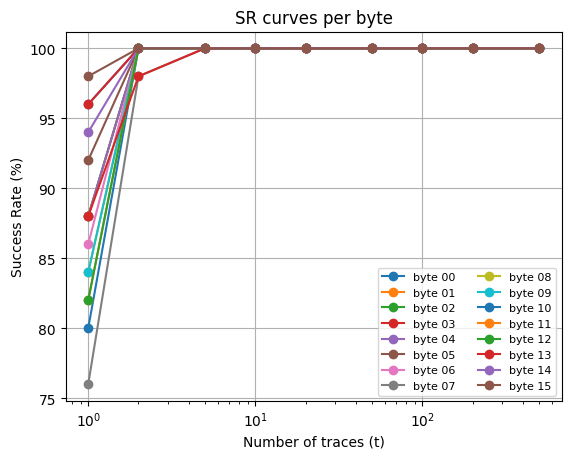

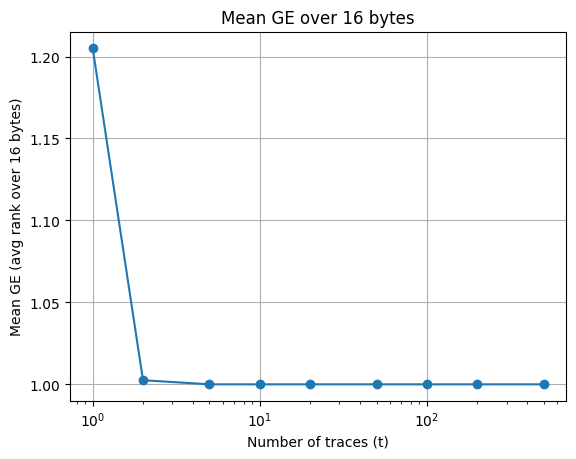

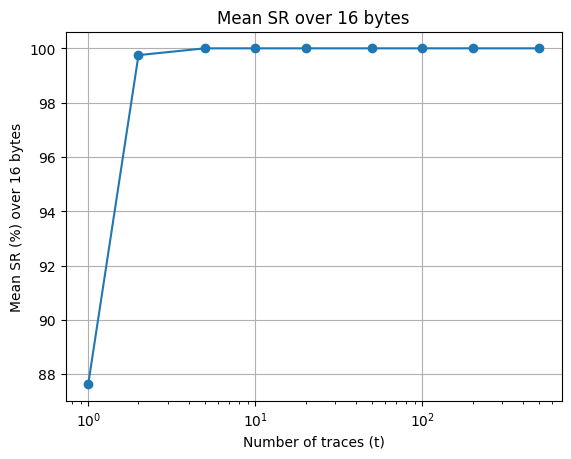

In [ ]:
guessed_key = np.zeros(16, dtype=np.uint8)
loglik_list = [None]*16  # 바이트별 loglik 저장

for byte_idx in range(16):
    print(f"\n===== BYTE {byte_idx:02d} =====")

    # (1) 라벨 생성
    _, Y = interm_and_onehot(pt, keys, byte_idx) # 첫 번째 반환값(중간값)은 받아서 무시하고, 두 번째 반환값만 Y에 받음
    Y_train, Y_val, Y_test = Y[train_idx], Y[val_idx], Y[test_idx]

    # (2) 학습/평가
    model, m = train_model(
        X_train, Y_train,
        X_val,   Y_val,
        X_test,  Y_test,
        input_len=X.shape[1],
        verbose=0,
    )
    print(f"acc train/val/test = {m['train_acc']:.4f} / {m['val_acc']:.4f} / {m['test_acc']:.4f}")

    # (3) 공격 데이터에 대해 한 번 예측 
    probs = model.predict(X_test, batch_size=256, verbose=0)  # (5000,256) 각 중간값이 될 확률

    # (4) loglik 만들기 (GE/SR에도 쓰고, key score에도 재사용)
    loglik = loglik_matrix_from_probs(probs, pt_test, byte_idx)
    loglik_list[byte_idx] = loglik

    # (5) 후보키 점수/정렬/베스트키
    scores = loglik.sum(axis=0) # (256,)
    order  = np.argsort(scores)[::-1] # 점수 내림차순 후보키 인덱스
    best_k = int(order[0]) # 1등 후보키(0~255)
    guessed_key[byte_idx] = best_k

    top5 = [f"0x{int(k):02x}" for k in order[:5]]
    print(f"[byte {byte_idx:02d}] best=0x{best_k:02x}  top5={top5}")

print("\n=== RESULT ===")
print("Guessed key:", " ".join(f"{b:02x}" for b in guessed_key))
print("True key   :", " ".join(f"{b:02x}" for b in true_key))

# GE/SR 계산 + 그래프
print("\n=== GE / SR (per byte) ===")

N_attack = X_test.shape[0]
steps = np.array([1, 2, 5, 10, 20, 50, 100, 200, N_attack], dtype=int)
steps = steps[steps <= N_attack]

ge_list = []
sr_list = []
steps_used_ref = None

for byte_idx in range(16):
    steps_used, ge, sr = compute_ge_sr(
        loglik_list[byte_idx],
        true_key[byte_idx],
        n_runs=50,
        steps=steps,
        seed=78 + byte_idx
    )

    if steps_used_ref is None:
        steps_used_ref = steps_used

    ge_list.append(ge)   # (T,)
    sr_list.append(sr)   # (T,)

    s = "  ".join([f"{t}:GE {g:.2f}, SR {r*100:.0f}% " for t, g, r in zip(steps_used, ge, sr)])
    print(f"[byte {byte_idx:02d}] {s}")

GE = np.vstack(ge_list)   # (16, T)
SR = np.vstack(sr_list)   # (16, T)

# ---- (1) GE 그래프 ----
plt.figure()
for byte_idx in range(16):
    plt.plot(steps_used_ref, GE[byte_idx], marker='o', label=f'byte {byte_idx:02d}')
plt.xscale('log')
plt.grid(True)
plt.xlabel('Number of traces (t)')
plt.ylabel('Guessing Entropy (avg rank)')
plt.title('GE curves per byte')
plt.legend(ncol=2, fontsize=8)
plt.show()

# ---- (2) SR 그래프 ----
plt.figure()
for byte_idx in range(16):
    plt.plot(steps_used_ref, SR[byte_idx] * 100.0, marker='o', label=f'byte {byte_idx:02d}')
plt.xscale('log')
plt.grid(True)
plt.xlabel('Number of traces (t)')
plt.ylabel('Success Rate (%)')
plt.title('SR curves per byte')
plt.legend(ncol=2, fontsize=8)
plt.show()

# 바이트 평균 GE/SR
plt.figure()
plt.plot(steps_used_ref, GE.mean(axis=0), marker='o')
plt.xscale('log')
plt.grid(True)
plt.xlabel('Number of traces (t)')
plt.ylabel('Mean GE (avg rank over 16 bytes)')
plt.title('Mean GE over 16 bytes')
plt.show()

plt.figure()
plt.plot(steps_used_ref, SR.mean(axis=0) * 100.0, marker='o')
plt.xscale('log')
plt.grid(True)
plt.xlabel('Number of traces (t)')
plt.ylabel('Mean SR (%) over 16 bytes')
plt.title('Mean SR over 16 bytes')
plt.show()